In [1]:
import awkward as ak
import numpy as np
import torch
from torch import nn
import uproot
import matplotlib.pyplot as plt
import matplotlib.text

from atlasopenmagic import install_from_environment

import atlasopenmagic as atom
atom.set_release('2025e-13tev-beta')

skim = '4lep'
files_list_background = atom.get_urls('700600', skim, protocol = 'https', cache=True)
files_list_BSM1 = atom.get_urls('345060', skim, protocol = 'https', cache=True)
background = uproot.open(files_list_background[0] +':analysis')
bsm = uproot.open(files_list_BSM1[0] +':analysis')
attributes = ['pt','eta','phi','e','charge','flavor','tight']
aliases_dict = {'pt':'lep_pt','eta':'lep_eta','phi':'lep_phi','e':'lep_e',
                           'charge':'lep_charge','flavor':'lep_type','tight':'lep_isTightID'}
leps_bd = background.arrays(attributes, aliases = aliases_dict)
leps_bsm = bsm.arrays(attributes, aliases=aliases_dict)

Fetching metadata for release: 2025e-13tev-beta...
Fetching datasets: 100%|██████████| 374/374 [00:00<00:00, 545.11datasets/s]
✓ Successfully cached 374 datasets.
Active release: 2025e-13tev-beta. (Datasets path: REMOTE)


In [3]:
n_leps = 4

leps_bd = leps_bd[np.argsort(leps_bd.pt, axis=1)][:,::-1][:,:4]
leps_bsm = leps_bsm[np.argsort(leps_bsm.pt, axis=1)][:,::-1][:,:4]

pt_bd = ak.to_numpy(leps_bd['pt'])
pt_bsm = ak.to_numpy(leps_bsm['pt'])
eta_bd = ak.to_numpy(leps_bd['eta'])
eta_bsm = ak.to_numpy(leps_bsm['eta'])
phi_bd = ak.to_numpy(leps_bd['phi'])
phi_bsm = ak.to_numpy(leps_bsm['phi'])
e_bd = ak.to_numpy(leps_bd['e'])
e_bsm = ak.to_numpy(leps_bsm['e'])
charge_bd = ak.to_numpy(leps_bd['charge'])
charge_bsm = ak.to_numpy(leps_bsm['charge'])
flavor_bd = ak.to_numpy(leps_bd['flavor'])
flavor_bsm = ak.to_numpy(leps_bsm['flavor'])
tight_bd = ak.to_numpy(leps_bd['tight'])
tight_bsm = ak.to_numpy(leps_bsm['tight'])

In [6]:
features_bd = np.concatenate([pt_bd, eta_bd, phi_bd, e_bd], axis=1)
features_bsm = np.concatenate([pt_bsm, eta_bsm, phi_bsm, e_bsm], axis=1)
X_tensor_bd = torch.from_numpy(features_bd).type(torch.float)
X_tensor_validate = torch.from_numpy(features_bsm).type(torch.float)

print(X_tensor_bd.shape)

torch.Size([11458, 16])


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test = train_test_split(X_tensor_bd, test_size=0.2, train_size=0.8)

In [5]:
device = "mps" if torch.backends.mps.is_available() else "cpu"

In [9]:
n_features = 16

In [42]:
class AnomalyAE(nn.Module):
    def __init__(self, n_features, bottleneck=12):
            super().__init__()
            self.encoder = nn.Sequential(
                nn.Linear(n_features, 24),
                nn.ReLU(),
                nn.Linear(24, bottleneck)
            )
            self.decoder = nn.Sequential(
                nn.Linear(bottleneck, 24),
                nn.ReLU(),
                nn.Linear(24, n_features)
            )
    
    def forward(self,  x):
        z = self.encoder(x)
        return self.decoder(z)

In [43]:
model = AnomalyAE(n_features=n_features).to(device)
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [11]:
mean = X_train.mean(dim=0, keepdim=True)
std = X_train.std(dim=0, keepdim=True)
std[std == 0] = 1.0

X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

In [12]:
X_train, X_test = X_train.to(device), X_test.to(device)

In [44]:
epochs = 500

for epoch in range(epochs):
    model.train()
    reconstructed = model(X_train)
    loss = loss_fn(reconstructed, X_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.inference_mode():
        test_recon = model(X_test)
        test_loss = loss_fn(test_recon, X_test)

    if epoch % 20 == 0:
        print(f"Epoch = {epoch}, Train loss: {loss:.5f}, Test loss: {test_loss:.5f}")

Epoch = 0, Train loss: 1.03193, Test loss: 1.03224
Epoch = 20, Train loss: 0.49228, Test loss: 0.44940
Epoch = 40, Train loss: 0.32350, Test loss: 0.29327
Epoch = 60, Train loss: 0.19967, Test loss: 0.18466
Epoch = 80, Train loss: 0.14414, Test loss: 0.15126
Epoch = 100, Train loss: 0.10931, Test loss: 0.11615
Epoch = 120, Train loss: 0.09129, Test loss: 0.09762
Epoch = 140, Train loss: 0.07873, Test loss: 0.08335
Epoch = 160, Train loss: 0.06952, Test loss: 0.07602
Epoch = 180, Train loss: 0.06538, Test loss: 0.07584
Epoch = 200, Train loss: 0.06017, Test loss: 0.06978
Epoch = 220, Train loss: 0.05968, Test loss: 0.07178
Epoch = 240, Train loss: 0.05519, Test loss: 0.06529
Epoch = 260, Train loss: 0.05322, Test loss: 0.06300
Epoch = 280, Train loss: 0.05287, Test loss: 0.06305
Epoch = 300, Train loss: 0.05022, Test loss: 0.06092
Epoch = 320, Train loss: 0.05010, Test loss: 0.06112
Epoch = 340, Train loss: 0.04681, Test loss: 0.05864
Epoch = 360, Train loss: 0.04428, Test loss: 0.05705

In [25]:
X_tensor_validate = X_tensor_validate.to(device)
X_tensor_bd = X_tensor_bd.to(device)

In [30]:
print(X_tensor_validate.shape)
print(X_tensor_bd.shape)

torch.Size([424880, 16])
torch.Size([11458, 16])


In [31]:
shuffled_indices = torch.randperm(len(X_tensor_validate))
X_tensor_validate_cropped = X_tensor_validate[shuffled_indices[:11458]]

In [36]:
mean = X_tensor_validate_cropped.mean(dim=0, keepdim=True)
std = X_tensor_validate_cropped.std(dim=0, keepdim=True)
std[std == 0] = 1.0

X_train = (X_tensor_validate_cropped - mean) / std

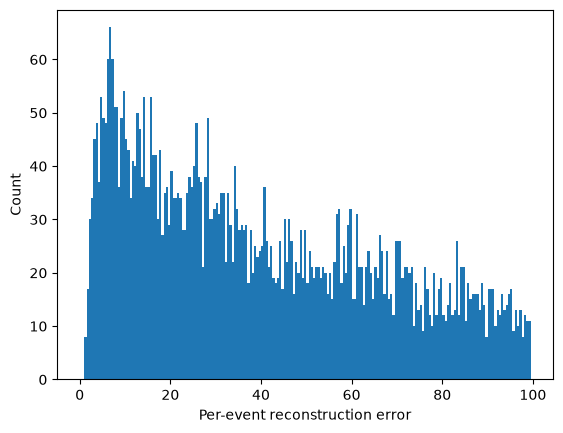

In [46]:
def reconstruction_error(model, X):
    model.eval()
    with torch.inference_mode():
        recon = model(X)
        return ((recon - X) ** 2).mean(dim=1)

test_scores = reconstruction_error(model, X_tensor_bd)

plt.hist(test_scores.cpu().numpy(), bins=np.arange(0, 100, 0.5))
plt.xlabel("Per-event reconstruction error")
plt.ylabel("Count")
plt.show()